In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import pandas as pd
import torch

DATA_DIR = Path("data")
TORONTO = DATA_DIR / Path("toronto")
TIMIT = DATA_DIR / Path("timit")

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

In [3]:
if not TORONTO.exists():
    !bash load_toronto.sh
    
if not TIMIT.exists():
    !bash load_timit.sh

## EDA

In [4]:
import librosa

toronto_sr = pd.Series(
    [librosa.get_samplerate(f) for f in TORONTO.rglob("*.wav")]
).value_counts()

timit_sr = pd.Series(
    [librosa.get_samplerate(f) for f in TIMIT.rglob("*.wav")]
).value_counts()

print(toronto_sr) # 44100
print(timit_sr) # 16000


44100    18303
Name: count, dtype: int64
16000    6300
Name: count, dtype: int64


In [5]:
TORONTO_SR = 44100
TIMIT_SR = 16000

In [6]:
labels = pd.read_json(TORONTO / "labels.jsonl", lines=True)

labels["dataset/toronto_0/toronto_0_0.wav"][0]

'Терміново! Загроза нового вторгнення в Україну нині дуже висока.'

In [13]:
toronto_ids = [f.name for f in TORONTO.glob("toronto_*")]

toronto_test_ids = set(['toronto_27', 'toronto_46', 'toronto_42', 'toronto_37', 'toronto_89', 'toronto_43',
'toronto_157', 'toronto_9', 'toronto_156', 'toronto_7', 'toronto_123', 'toronto_54', 'toronto_67',
'toronto_62', 'toronto_81', 'toronto_134', 'toronto_148', 'toronto_21', 'toronto_135', 'toronto_166',
'toronto_58'])

toronto_train_ids = set(toronto_ids) - set(toronto_test_ids)
print(f"intersection is 0: {len(toronto_test_ids & toronto_train_ids) == 0}")

toronto_df = []
for f in TORONTO.rglob("*.wav"):
    toronto_df.append({
        "filename": f.name,
        "speaker_id": f.parent.name,
        "duration": librosa.get_duration(path=f, sr=TORONTO_SR),
        "label": labels[f"dataset/{f.parent.name}/{f.name}"][0]
    })
toronto_df = pd.DataFrame(toronto_df)

toronto_train_df = toronto_df[toronto_df["speaker_id"].isin(toronto_train_ids)]
toronto_test_df  = toronto_df[toronto_df["speaker_id"].isin(toronto_test_ids)]

missing_labels = toronto_df[toronto_df["label"] == ""] # 93 entries that probably should be removed from the test/training datasets
missing_labels_train = toronto_train_df[toronto_train_df["label"] == ""] # 72 from train part



intersection is 0: True


In [30]:
import matplotlib.pyplot as plt

def plot_toronto_distributions(df, title_prefix=""):
    _, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(df["duration"], bins=40, edgecolor="black")
    axes[0].set_title(f"{title_prefix} duration distribution")
    axes[0].set_xlabel("duration (seconds)")
    axes[0].set_ylabel("number of files")

    word_counts = df["label"].fillna("").str.split().str.len()
    axes[1].hist(word_counts, bins=40, edgecolor="black")
    axes[1].set_title(f"{title_prefix} words per label")
    axes[1].set_xlabel("word count")
    axes[1].set_ylabel("number of files")

    files_per_speaker = df["speaker_id"].value_counts()
    axes[2].hist(files_per_speaker, bins=40, edgecolor="black")
    axes[2].set_title(f"{title_prefix} files per speaker")
    axes[2].set_xlabel("files per speaker")
    axes[2].set_ylabel("number of speakers")

    plt.tight_layout()
    plt.show()

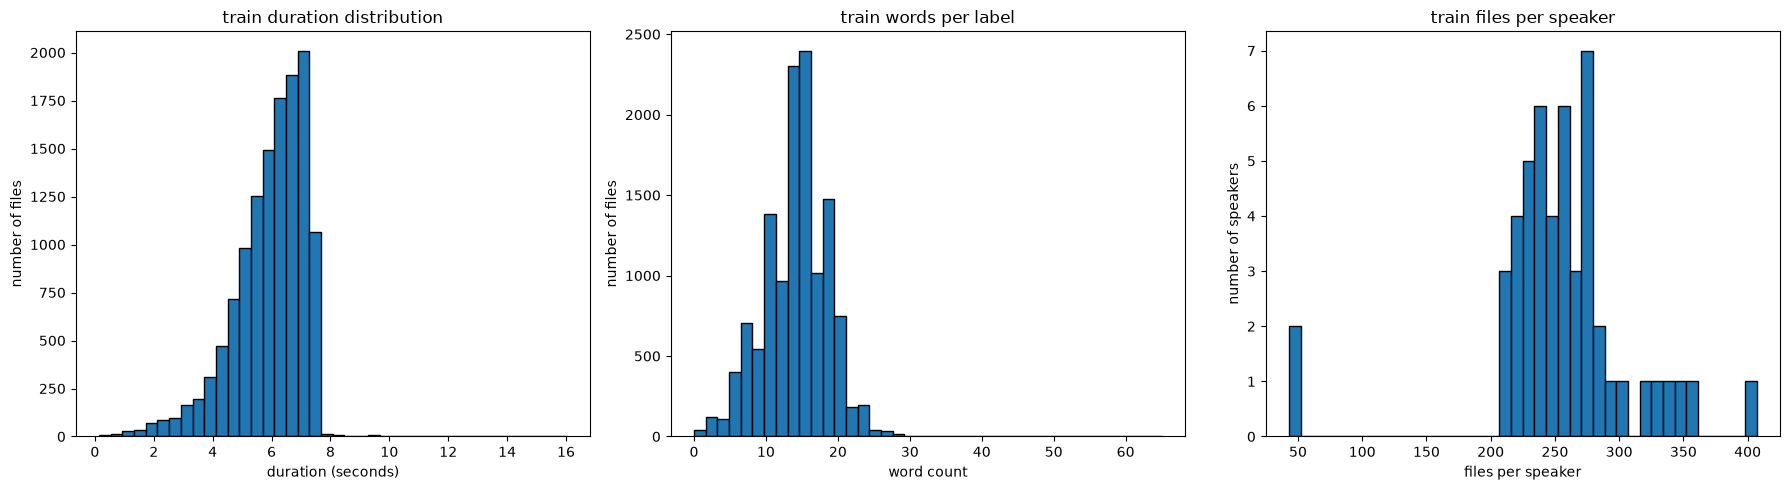

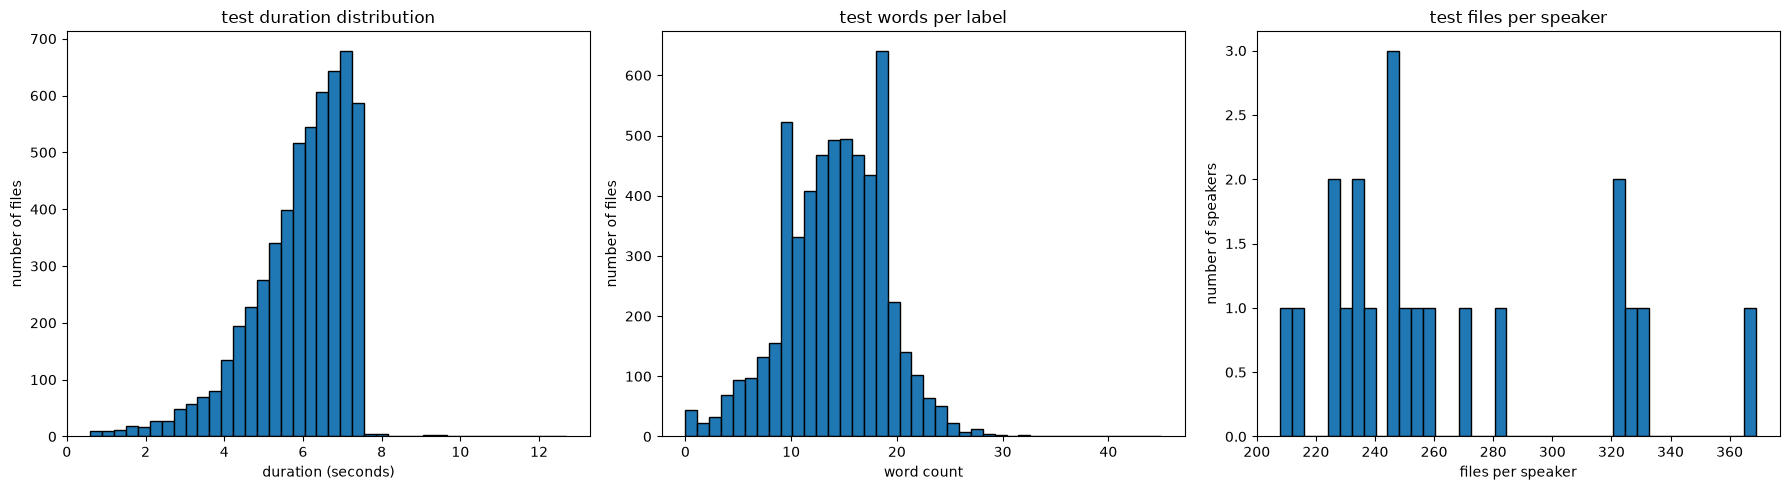

In [31]:
plot_toronto_distributions(toronto_train_df, "train")
plot_toronto_distributions(toronto_test_df, "test")

In [27]:
TIMIT_META_TEST = TIMIT / "test_data.csv"
TIMIT_META_TRAIN = TIMIT / "train_data.csv"

TIMIT_TEST = TIMIT / "data/test"
TIMIT_TRAIN = TIMIT / "data/train"

timit_train_meta = pd.read_csv(TIMIT_META_TRAIN)
timit_test_meta  = pd.read_csv(TIMIT_META_TEST)

timit_train_meta.head()

def build_timit_df(meta):
    audio = meta[meta["is_converted_audio"] == True]

    timit_df = []
    for _, row in audio.iterrows():
        wav = TIMIT / "data" / row["path_from_data_dir"]
        phn = wav.with_name(row["filename"].replace(".WAV.wav", ".PHN"))
        phonemes = [line.split()[2] for line in phn.read_text().splitlines()]
        timit_df.append({
            "filename": row["filename"],
            "speaker_id": row["speaker_id"],
            "dialect_region": row["dialect_region"],
            "sentence_type": row["filename"][:2],
            "duration": librosa.get_duration(path=wav, sr=TIMIT_SR),
            "gender": row["speaker_id"][0],
            "phonemes": phonemes,
        })
    return pd.DataFrame(timit_df)

timit_train_df = build_timit_df(timit_train_meta)
timit_test_df  = build_timit_df(timit_test_meta)

print(len(timit_train_df))
print(len(timit_test_df))


4620
1680


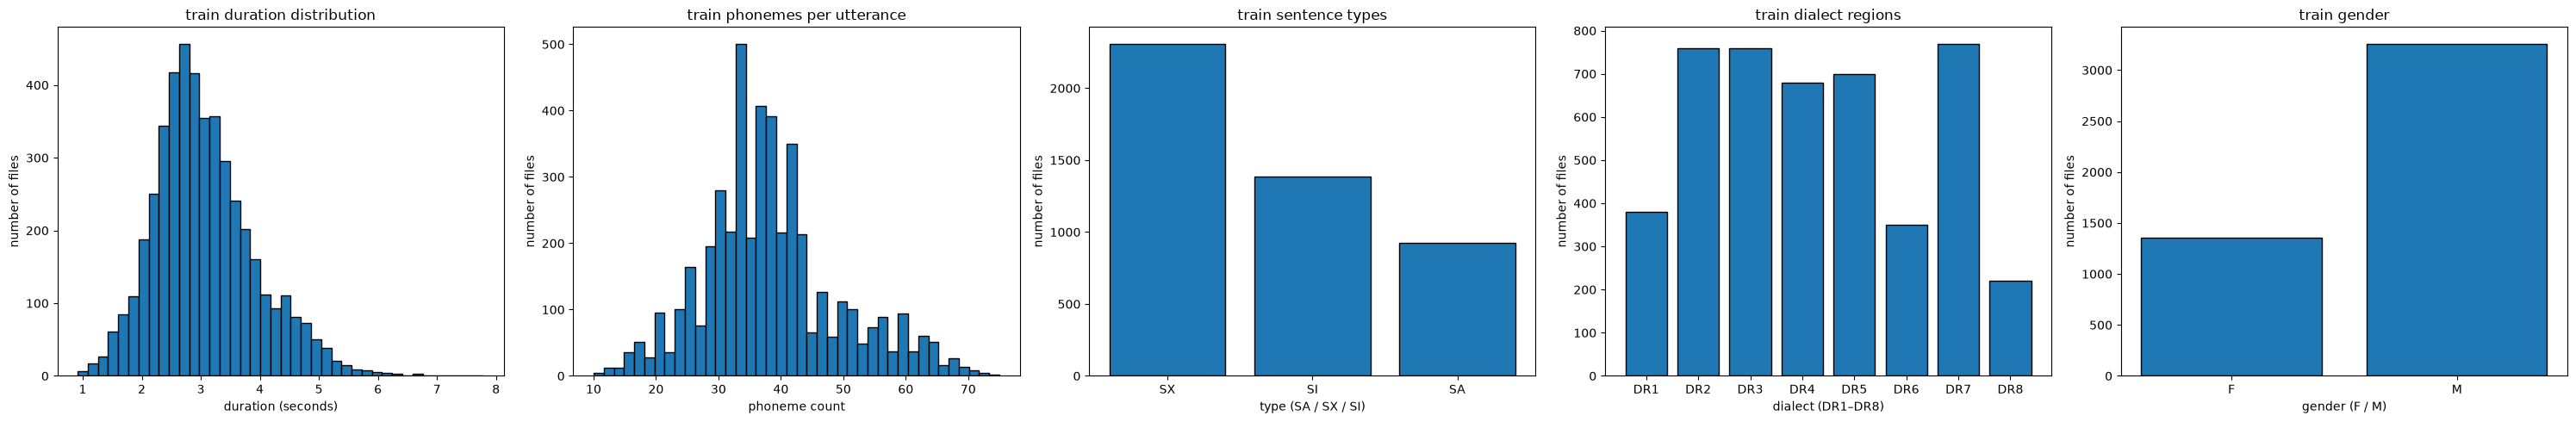

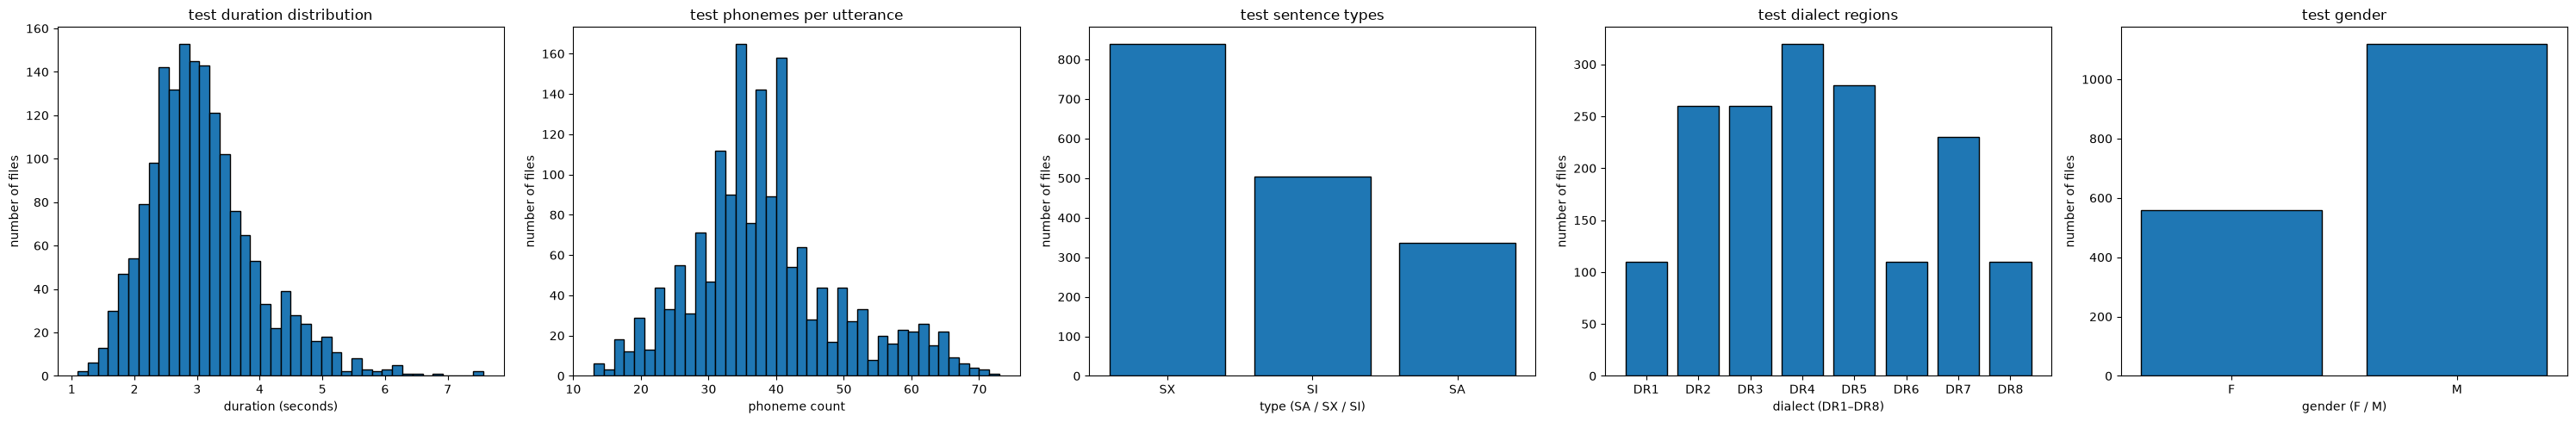

In [28]:
def plot_timit_distributions(df, title_prefix=""):
    _, axes = plt.subplots(1, 5, figsize=(30, 5))

    axes[0].hist(df["duration"], bins=40, edgecolor="black")
    axes[0].set_title(f"{title_prefix} duration distribution")
    axes[0].set_xlabel("duration (seconds)")
    axes[0].set_ylabel("number of files")

    phoneme_counts = df["phonemes"].str.len()
    axes[1].hist(phoneme_counts, bins=40, edgecolor="black")
    axes[1].set_title(f"{title_prefix} phonemes per utterance")
    axes[1].set_xlabel("phoneme count")
    axes[1].set_ylabel("number of files")

    sentence_types = df["sentence_type"].value_counts()
    axes[2].bar(sentence_types.index, sentence_types.values, edgecolor="black")
    axes[2].set_title(f"{title_prefix} sentence types")
    axes[2].set_xlabel("type (SA / SX / SI)")
    axes[2].set_ylabel("number of files")

    dialects = df["dialect_region"].value_counts().sort_index()
    axes[3].bar(dialects.index, dialects.values, edgecolor="black")
    axes[3].set_title(f"{title_prefix} dialect regions")
    axes[3].set_xlabel("dialect (DR1–DR8)")
    axes[3].set_ylabel("number of files")

    genders = df["gender"].value_counts().sort_index()
    axes[4].bar(genders.index, genders.values, edgecolor="black")
    axes[4].set_title(f"{title_prefix} gender")
    axes[4].set_xlabel("gender (F / M)")
    axes[4].set_ylabel("number of files")

    plt.tight_layout()
    plt.show()
    
plot_timit_distributions(timit_train_df, "train")
plot_timit_distributions(timit_test_df, "test")

we are removing the SA data from train/val split, 2 sentanses are read by all of the speakers, what will result in the data leakage.  
split by speaker, stratification by dialect, train will use both SX and SI data, while val only SI data. it will prevent sentance leakage. (in SI 1 sentance is read by 1 speaker, in SX one sentance is read by multiple)

## Train/validation split

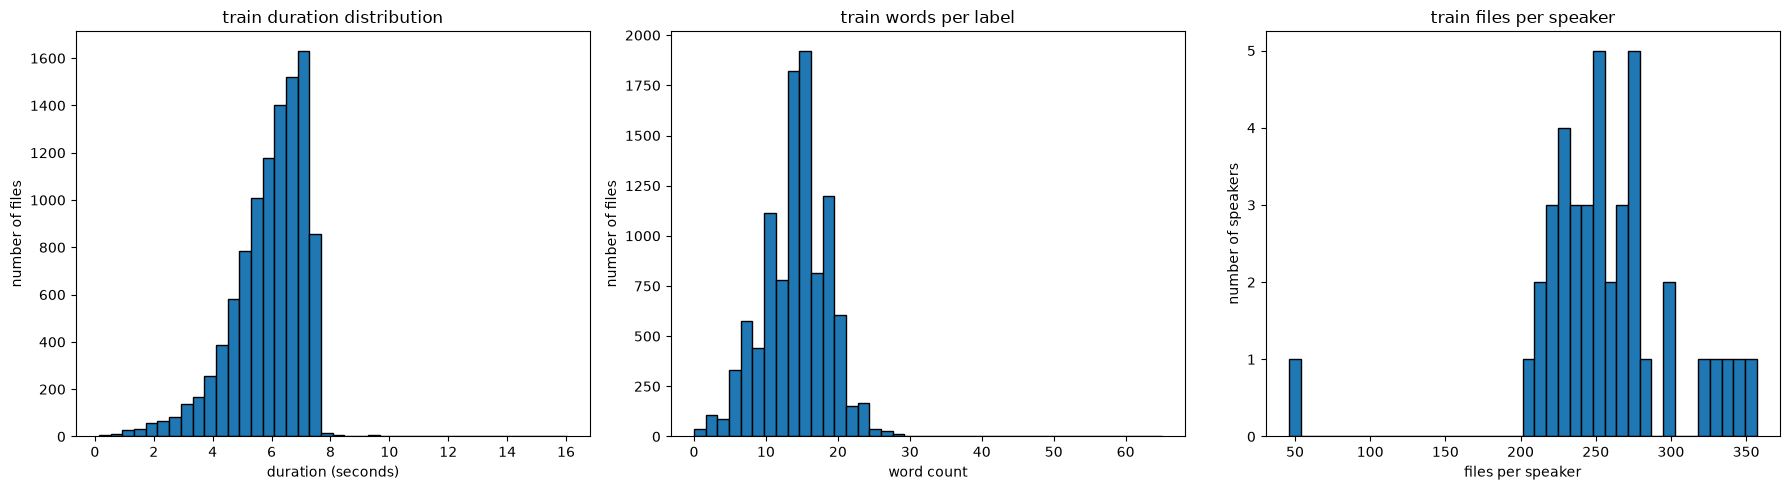

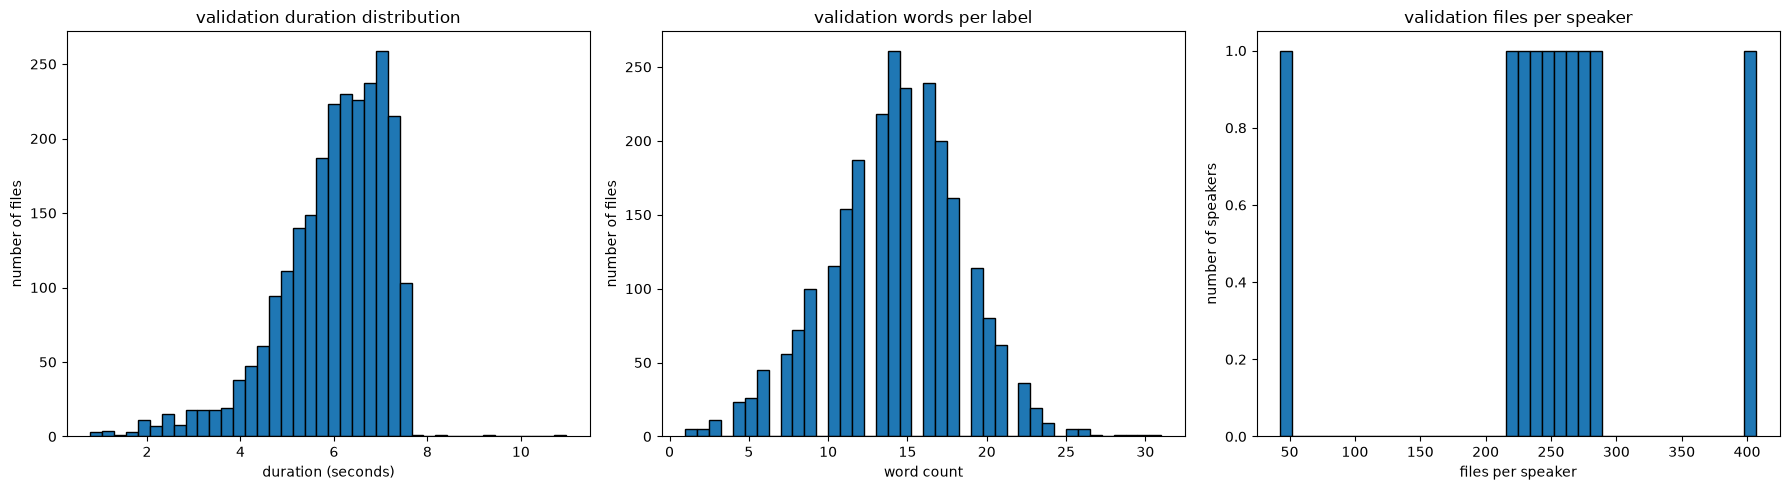

In [32]:
from sklearn.model_selection import GroupKFold

toronto_train_df = toronto_train_df[toronto_train_df["label"] != ""]

gkf = GroupKFold(n_splits=5)
train, val = next(gkf.split(toronto_train_df, groups=toronto_train_df["speaker_id"]))
toronto_tr_df, toronto_val_df = toronto_train_df.iloc[train], toronto_train_df.iloc[val]

plot_toronto_distributions(toronto_tr_df, "train")
plot_toronto_distributions(toronto_val_df, "validation")

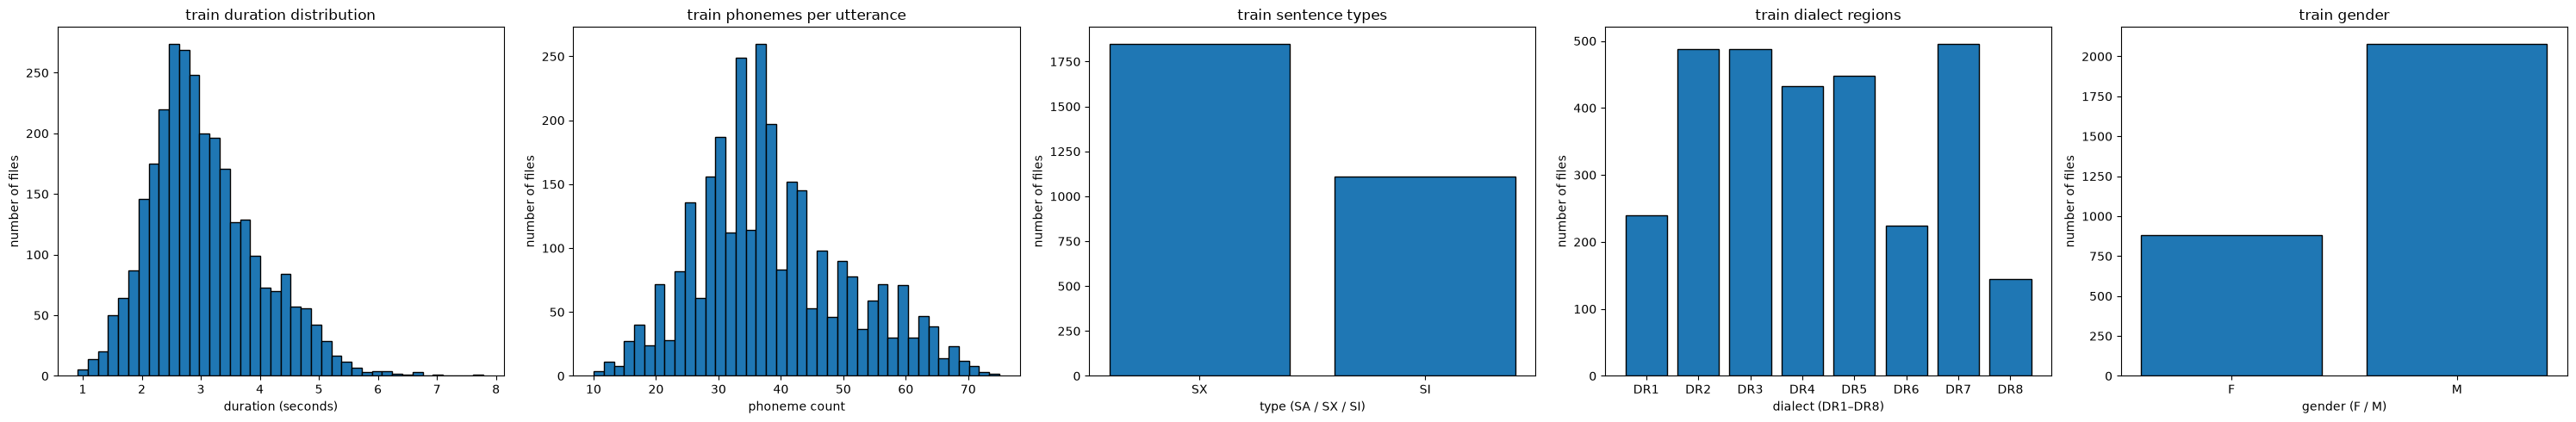

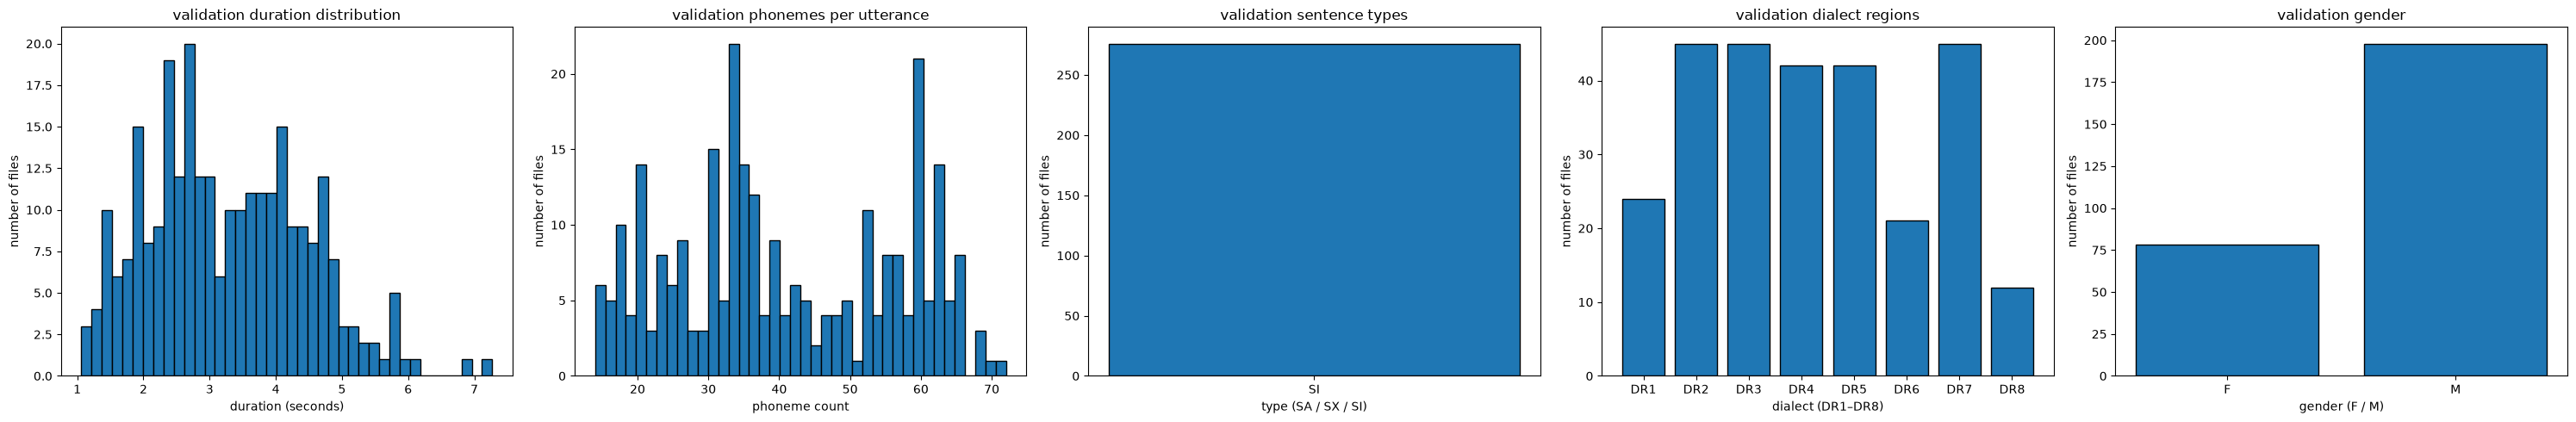

In [34]:
from sklearn.model_selection import StratifiedGroupKFold

timit_train_df = timit_train_df[timit_train_df["sentence_type"] != "SA"].copy()

timit_train_df["strat"] = timit_train_df["dialect_region"] + "_" + timit_train_df["gender"]
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train, val = next(sgkf.split(timit_train_df, timit_train_df["strat"], groups=timit_train_df["speaker_id"]))
timit_tr_df, timit_val_df = timit_train_df.iloc[train], timit_train_df.iloc[val]

timit_val_df = timit_val_df[timit_val_df["sentence_type"] == "SI"]

plot_timit_distributions(timit_tr_df, "train")
plot_timit_distributions(timit_val_df, "validation")